In [1]:
# Data 가져오기와 데이터 분류
from tensorflow import keras
from sklearn.model_selection import train_test_split

In [3]:
(train_input, train_target), (test_input, test_target) = \
       keras.datasets.fashion_mnist.load_data()
    
# 정규화
train_scaled = train_input / 255.0

# train과 valid data 생성
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size = 0.2,
        random_state=42
    )

In [10]:
# Model 함수

def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28,28)))
    model.add(keras.layers.Dense(100, activation='relu'))
    if a_layer:
        model.add(a_layer)
    model.add(keras.layers.Dense(10, activation='softmax'))
    return model

In [11]:
# 모델 구성 및 Summary
model = model_fn()
model.summary()

c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# 훈련 및 과정에 대한 history 보기
model.compile(
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history = model.fit(train_scaled,train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8134 - loss: 0.5270
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8601 - loss: 0.3869
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8749 - loss: 0.3507
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8810 - loss: 0.3300
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8867 - loss: 0.3159


In [14]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

#### 손실곡선

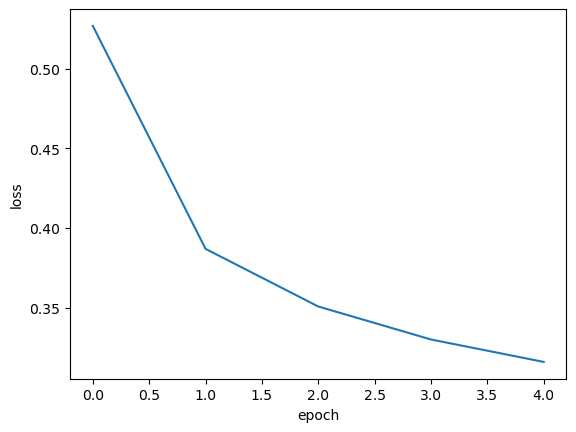

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

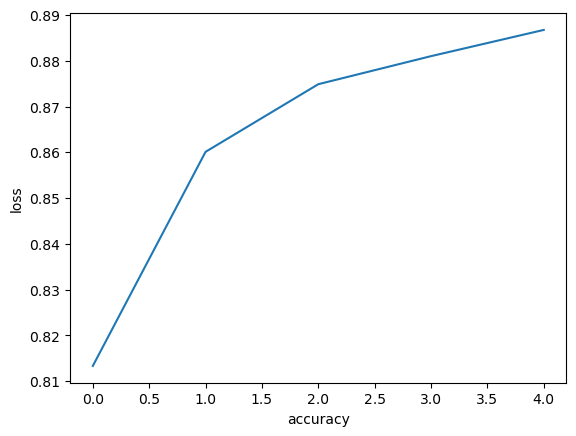

In [ ]:
plt.plot(history.history['accuracy'])
plt.xlabel("accuracy")
plt.ylabel("loss")
plt.show()

> epochs를 늘리면 정확도가 더 올라가고 손실이 더 떨어질것 같음

---
#### 반복 훈련의 증가(epochs의 증가)

In [17]:
model = model_fn()
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
        train_scaled,
        train_target,
        epochs = 20
)

Epoch 1/20


c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8126 - loss: 0.5353
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8582 - loss: 0.3933
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8717 - loss: 0.3555
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8811 - loss: 0.3330
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8851 - loss: 0.3191
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8900 - loss: 0.3065
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8934 - loss: 0.2961
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8981 - loss: 0.2867
Epoch 9/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9013 - loss: 0.2795
Epoch 10/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9022 - loss: 0.2718
Epoch 11/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9055 - loss: 0.2644
Epoch 12/20
1500/1500 ━━━━━━━━━━━━━━━━━━━

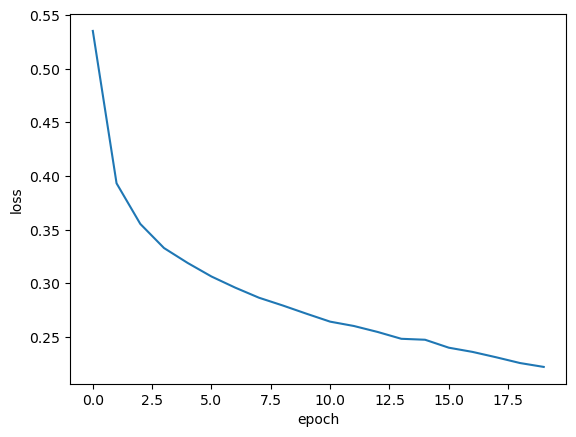

In [ ]:
# Histroy의 시각화
plt.plot(history.history['loss'])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

---
#### 검증 손실
: 검증세트 대한 정확도를 파악

In [19]:
model = model_fn()
model.compile(
    loss="sparse_categorical_crossentropy",
    metrics = ['accuracy']
)
history = model.fit(
            train_scaled,
            train_target,
            epochs=20,
            validation_data=(val_scaled, val_target)
)

Epoch 1/20


c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8106 - loss: 0.5373 - val_accuracy: 0.8407 - val_loss: 0.4528
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8576 - loss: 0.3954 - val_accuracy: 0.8618 - val_loss: 0.3853
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8713 - loss: 0.3577 - val_accuracy: 0.8607 - val_loss: 0.3845
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8795 - loss: 0.3349 - val_accuracy: 0.8683 - val_loss: 0.3872
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8851 - loss: 0.3214 - val_accuracy: 0.8676 - val_loss: 0.3908
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8901 - loss: 0.3066 - val_accuracy: 0.8736 - val_loss: 0.3681
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8923 - loss: 0.2968 - val_accuracy: 0.8785 - val_loss: 0.3580
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8970 - loss: 0.2872 - val_accurac

In [20]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

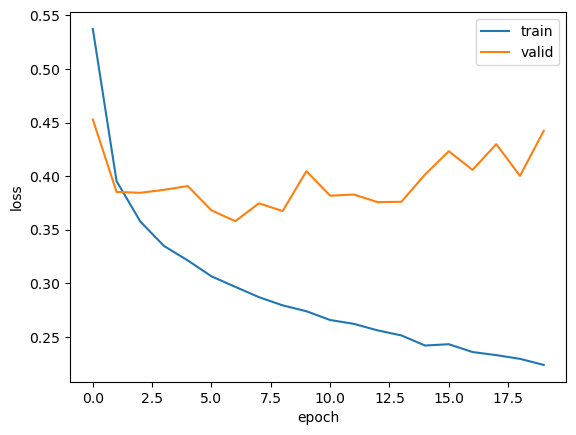

In [21]:
# Histroy의 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()

> 훈련세트는 epochs가 증가됨에 따라 손실이 떨어지고 있으나,                   
검증세트는 epochs가 증가에 따라 초반에는 손실이 떨어지나 진행하면 할수록                  
손실율이 증가한다.               
이 모델은 훈련세트의 정확도가 높아 좋지만 검증세트에는 적합하지 않은                     
과대적합 모델이다.

-----
#### Optimizer 사용


In [22]:
model = model_fn()
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics = ['accuracy']
)
history = model.fit(
            train_scaled,
            train_target,
            epochs=20,
            validation_data=(val_scaled, val_target)
)

Epoch 1/20


c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8141 - loss: 0.5318 - val_accuracy: 0.8507 - val_loss: 0.4270
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8546 - loss: 0.4036 - val_accuracy: 0.8618 - val_loss: 0.3833
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8696 - loss: 0.3602 - val_accuracy: 0.8758 - val_loss: 0.3511
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8789 - loss: 0.3316 - val_accuracy: 0.8621 - val_loss: 0.3829
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8869 - loss: 0.3096 - val_accuracy: 0.8796 - val_loss: 0.3380
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8911 - loss: 0.2951 - val_accuracy: 0.8811 - val_loss: 0.3315
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8959 - loss: 0.2806 - val_accuracy: 0.8832 - val_loss: 0.3252
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8992 - loss: 0.2693 - val_accurac

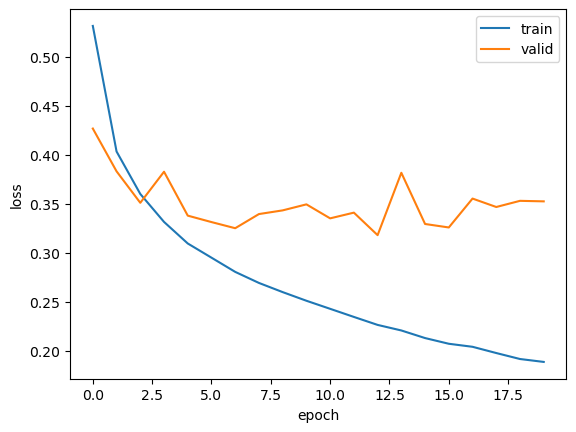

In [23]:
# Histroy의 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()

> optimizer(최적화 알고리즘)을 사용해서 train과 valid의 손실율이 조금더                   
비슷해지고 valid의 손실율이 안정화 되었으나 아직 과대적합이다.

----
#### Dropout
: 훈련시 각 데이터를 처리할때 데이터의 갯수를 랜덤으로 줄인다.

In [24]:
# model에 dropout을 추가
model = model_fn(keras.layers.Dropout(0.3)) # 0.3:%
model.summary()

c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics = ['accuracy']
)
history = model.fit(
            train_scaled,
            train_target,
            epochs=20,
            validation_data=(val_scaled, val_target)
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7908 - loss: 0.5932 - val_accuracy: 0.8454 - val_loss: 0.4320
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8406 - loss: 0.4415 - val_accuracy: 0.8550 - val_loss: 0.4049
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8515 - loss: 0.4050 - val_accuracy: 0.8602 - val_loss: 0.3779
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8613 - loss: 0.3806 - val_accuracy: 0.8671 - val_loss: 0.3581
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8658 - loss: 0.3654 - val_accuracy: 0.8740 - val_loss: 0.3441
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8710 - loss: 0.3531 - val_accuracy: 0.8750 - val_loss: 0.3408
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8746 - loss: 0.3417 - val_accuracy: 0.8783 - val_loss: 0.3386
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8770 - loss: 0.3333 - 

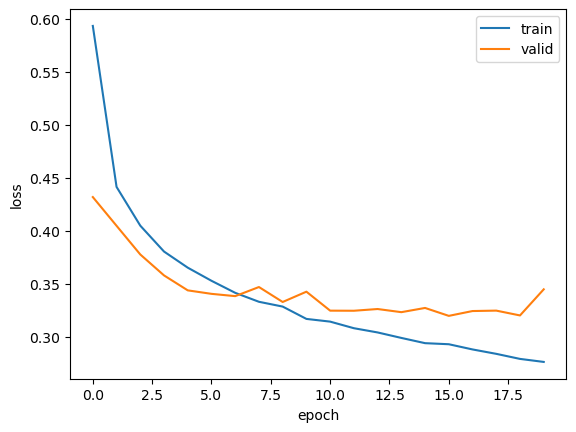

In [26]:
# Histroy의 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()

> epoch가 9일 경우 train과 valid의 차이가 적은 것 같다.                     
기본적으로 훈련세트의 손실이 검증세트보다 적게 나오는 epochs를 선택

In [27]:
model = model_fn(keras.layers.Dropout(0.3))

model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics = ['accuracy']
)
history = model.fit(
            train_scaled,
            train_target,
            epochs=9,
            validation_data=(val_scaled, val_target)
)

Epoch 1/9


c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7879 - loss: 0.5984 - val_accuracy: 0.8424 - val_loss: 0.4324
Epoch 2/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8396 - loss: 0.4434 - val_accuracy: 0.8574 - val_loss: 0.3973
Epoch 3/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8508 - loss: 0.4085 - val_accuracy: 0.8692 - val_loss: 0.3661
Epoch 4/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8611 - loss: 0.3867 - val_accuracy: 0.8732 - val_loss: 0.3531
Epoch 5/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8654 - loss: 0.3708 - val_accuracy: 0.8711 - val_loss: 0.3502
Epoch 6/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8684 - loss: 0.3569 - val_accuracy: 0.8692 - val_loss: 0.3611
Epoch 7/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8724 - loss: 0.3471 - val_accuracy: 0.8779 - val_loss: 0.3390
Epoch 8/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8756 - loss: 0.3373 - val_accuracy: 0.87

----
#### 모델의 저장과 복원

In [28]:
# 모델의 저장
model.save("../Data/model_fashion.keras")

In [29]:
# 복원
model1 = keras.models.load_model("../Data/model_fashion.keras")

In [30]:
# 사용
model1.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8798 - loss: 0.3369


[0.33688798546791077, 0.8797500133514404]

----
#### Callbacks
: 훈련수행시 손실값이 제일 작은 모델을 저장해준다. <- 굉장히 편함

In [32]:
model = model_fn(keras.layers.Dropout(0.3))

model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics = ['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_model.keras")

history = model.fit(
            train_scaled,
            train_target,
            epochs=20,
            validation_data=(val_scaled, val_target),
            callbacks = [checkpoint_cb]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7912 - loss: 0.5910 - val_accuracy: 0.8432 - val_loss: 0.4466
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8394 - loss: 0.4446 - val_accuracy: 0.8586 - val_loss: 0.3928
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8530 - loss: 0.4048 - val_accuracy: 0.8625 - val_loss: 0.3739
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8594 - loss: 0.3841 - val_accuracy: 0.8659 - val_loss: 0.3620
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8651 - loss: 0.3667 - val_accuracy: 0.8777 - val_loss: 0.3381
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8685 - loss: 0.3559 - val_accuracy: 0.8704 - val_loss: 0.3524
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8732 - loss: 0.3441 - val_accuracy: 0.8766 - val_loss: 0.3372
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8761 - loss: 0.3363 - 

In [34]:
# 복원
model1 = keras.models.load_model("../Data/best_model.keras")
# 사용
model1.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8867 - loss: 0.3285


[0.3284904658794403, 0.8867499828338623]

-----
#### Early-Stopping(조기종료)
: Callbacks를 끝까지 기다리는 것이 아니고 patience(Hyper parameter)을                
선정하여 한계값을 정해 실행한다.

In [41]:
model = model_fn(keras.layers.Dropout(0.3))

model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics = ['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_model.keras", save_best_only = True)
early_stopping_cb= keras.callbacks.EarlyStopping(
                    patience=2,
                    restore_best_weights=True                  
)

history = model.fit(
            train_scaled,
            train_target,
            epochs=20,
            validation_data=(val_scaled, val_target),
            callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7917 - loss: 0.5905 - val_accuracy: 0.8393 - val_loss: 0.4305
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8407 - loss: 0.4404 - val_accuracy: 0.8602 - val_loss: 0.3886
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8528 - loss: 0.4020 - val_accuracy: 0.8606 - val_loss: 0.3752
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8610 - loss: 0.3809 - val_accuracy: 0.8707 - val_loss: 0.3472
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8678 - loss: 0.3647 - val_accuracy: 0.8733 - val_loss: 0.3444
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8697 - loss: 0.3518 - val_accuracy: 0.8727 - val_loss: 0.3508
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8756 - loss: 0.3427 - val_accuracy: 0.8761 - val_loss: 0.3340
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8769 - loss: 0.3339 - 

In [ ]:
# 몇번째 epoch에서 stop되었는가?
early_stopping_cb.stopped_epoch

13

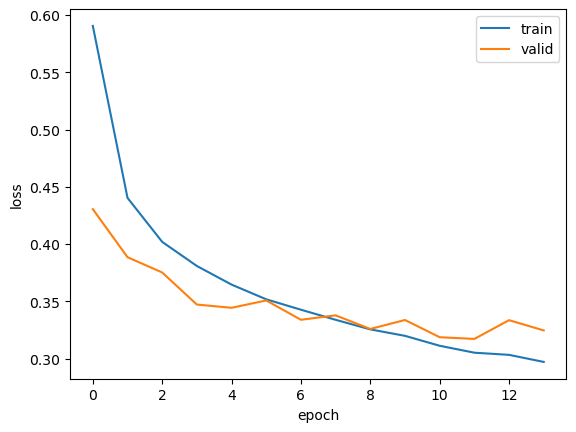

In [44]:
# Histroy의 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()

In [42]:
# 복원
model1 = keras.models.load_model("../Data/best_model.keras")
# 사용
model1.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8861 - loss: 0.3173


[0.31725019216537476, 0.8860833048820496]